<a href="https://colab.research.google.com/github/peter-adepoju/math-neuro-ml/blob/main/lesson1/Lesson1_Teaching_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Math for Neuroscience & Machine Learning**
## Lesson 1 — Vectors, Neural Population States, and Feature Space

**Course:** Math for Neuroscience & Machine Learning\
**Lesson:** Lesson 1\
**Notebook type:** Teaching notebook

> *"A snapshot of neural activity across a population of neurons, and a single row of measurements in a machine-learning dataset, are the same kind of mathematical object: a vector."*

---

### Welcome to the course

This course teaches mathematics through direct application. Every idea you encounter here is turned into runnable code, a plot you can look at, and a question about what
that plot means for real data. We will build the mathematical foundation needed to *read*,   *manipulate*, and *reason about* the kind of data that shows up in Machine learning and
Computational Neuroscience.

### Import Dependencies

In [ ]:
# SETUP CELL
from pathlib import Path
import shutil
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, Video, display
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import Normalize

RNG = np.random.default_rng(42)

# A small, colourblind-conscious palette and a matching set of markers, reused throughout.
PALETTE = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9']
MARKERS = ['o', 's', '^', 'D', 'v', 'P']

print("Setup complete.")

Setup complete.



### Interactive and animated plotting tools

Directly after each static figure, a **Plotly version** is included so that you can zoom, pan, rotate, inspect with the
mouse, and save from the toolbar.

In [ ]:

# INTERACTIVE/ANIMATION SETUP
PLOTLY_MARKERS = ['circle', 'square', 'triangle-up', 'diamond', 'triangle-down', 'cross']

PLOTLY_CONFIG = {
    'displaylogo': False,
    'responsive': True,
    'scrollZoom': True,
    'toImageButtonOptions': {
        'format': 'png',
        'scale': 2,
    },
}

ANIMATION_FPS = 20
ANIMATION_DPI = 140
ANIMATION_OUTPUT_DIR = Path('lesson1_animations')
ANIMATION_OUTPUT_DIR.mkdir(exist_ok=True)

def padded_limits(values, fraction=0.08, minimum_padding=1.0):
    # Return stable axis limits with a small padding around the data.
    values = np.asarray(values, dtype=float)
    lo = float(np.nanmin(values))
    hi = float(np.nanmax(values))
    span = hi - lo
    pad = minimum_padding if span == 0 else fraction * span
    return lo - pad, hi + pad

def display_matplotlib_animation(animation, fps=ANIMATION_FPS):
    # Show a Matplotlib animation with browser play/pause controls.
    display(HTML(animation.to_jshtml(fps=fps, default_mode='once')))

    output_path = ANIMATION_OUTPUT_DIR / filename
    writer = FFMpegWriter(
        fps=fps,
        bitrate=2500,
        metadata={'artist': 'Lesson 1 teaching notebook'},
    )
    animation.save(output_path, writer=writer, dpi=dpi)
    print(f'Saved MP4: {output_path.resolve()}')
    display(Video(str(output_path), embed=True))
    return output_path

print('Interactive plotting and animation tools are ready.')

Interactive plotting and animation tools are ready.


# **Motivation: one brain state as one vector**

Suppose three neurons are recorded **simultaneously**. At one moment in time, their firing
rates are:

$$\mathbf{r}_1 = (12,\ 4,\ 19) \ \text{spikes/s}$$

Together, these numbers describe **one thing**: the state of a small population of neurons at a particular instant.
Now suppose we record the same three neurons again, under a different stimulus:

$$\mathbf{r}_2 = (50,\ 8,\ 33) \ \text{spikes/s}$$

Two questions follow immediately:

- **How did the state change?** (subtract the vectors)
- **How far did it move?** (measure the length of that change)

We will answer both questions later in this lesson. For now, notice that both questions
only make sense because we treated each triple of numbers as *one object*.

In [ ]:
# The population state under two conditions
r_1 = np.array([12.0, 4.0, 19.0])   # spikes/s, stimulus 1
r_2 = np.array([50.0, 8.0, 33.0])   # spikes/s, stimulus 2

print("State 1:", r_1, "spikes/s")
print("State 2:", r_2, "spikes/s")

change = r_2 - r_1
distance_moved = np.linalg.norm(change)
print("\nChange in state (r_2 - r_1):", change, "spikes/s")
print(f"How far the population state moved: {distance_moved:.2f} spikes/s (Euclidean distance)")

State 1: [12.  4. 19.] spikes/s
State 2: [50.  8. 33.] spikes/s

Change in state (r_2 - r_1): [38.  4. 14.] spikes/s
How far the population state moved: 40.69 spikes/s (Euclidean distance)


Now the same idea, from machine learning. Suppose we have one observation — say, one house in a
dataset of house prices:

$$\mathbf{x} = (1416\ \text{sq ft},\ 3\ \text{bedrooms},\ 40\ \text{years})$$

These features form a **feature vector**. A predictive model receives this entire vector as its input.

In [ ]:
x_house = np.array([1416.0, 3.0, 40.0])
feature_names = ['size (sq ft)', 'bedrooms', 'age (years)']

print("Feature vector for this house:", x_house)
for name, value in zip(feature_names, x_house):
    print(f"  {name:14s}: {value}")

Feature vector for this house: [1416.    3.   40.]
  size (sq ft)  : 1416.0
  bedrooms      : 3.0
  age (years)   : 40.0


# **Part 1: Scalars versus Vectors**

A **scalar** is a single number. A **vector** is an ordered collection of numbers, treated
as one object.

| Object | Example | Dimensionality |
|---|---|---|
| Scalar firing rate (one neuron) | $23.5$ Hz | a single number |
| Neural population vector (three neurons) | $\mathbf{r}$ = (12, 4, 19) spikes/s | 3 |
| ML feature vector (one observation) | $\mathbf{x}^{(i)}$ = (1416, 3, 40) | 3 |
| Model-parameter vector | $\mathbf{w}$ = (w_1, w_2, w_3) | 3 |

**Dimensionality** is simply the number of coordinates.

In [ ]:
# Scalar vs. vector vs. parameter vector, side by side
single_neuron_rate = 23.5   # Hz -- a scalar

r_population = np.array([12.0, 4.0, 19.0])          # neural population vector (3 neurons)
x_observation = np.array([1416.0, 3.0, 40.0])       # ML feature vector (1 observation)
theta_params = np.array([0.10, 5.0, -2.0])          # a parameter vector (illustrative only)

print(f"Scalar (one neuron's rate):        {single_neuron_rate} Hz  (dimensionality: none -- a single number)")
print(f"Population vector (3 neurons):     {r_population} spikes/s  (dimensionality: {r_population.size})")
print(f"ML feature vector (1 observation): {x_observation}  (dimensionality: {x_observation.size})")
print(f"Parameter vector (illustrative):   {theta_params}  (dimensionality: {theta_params.size})")

Scalar (one neuron's rate):        23.5 Hz  (dimensionality: none -- a single number)
Population vector (3 neurons):     [12.  4. 19.] spikes/s  (dimensionality: 3)
ML feature vector (1 observation): [1416.    3.   40.]  (dimensionality: 3)
Parameter vector (illustrative):   [ 0.1  5.  -2. ]  (dimensionality: 3)


A parameter vector like $\mathbf{w}$ or $\boldsymbol{\theta}$ collects
the numbers a model *learns* (for example, one weight per feature). We are not fitting any
model in Lesson 1, we mention parameter vectors here only so you recognize them later as
"just another vector" once we do reach model fitting.

**Question:** if someone handed you the raw list `[12.0, 4.0, 19.0]` with no
further context, could you tell if it was a neural population vector or a feature
vector for a house? What information is missing?

## Part 2: Three Views of a Vector

The vector $\mathbf{v} = (4, -2)$ can be understood in three complementary ways:

1. **An ordered list of numbers:** a length-2 array. Useful for storing and
   computing.
2. **A directed displacement (an arrow):** starting at the origin, move 4 units along the
   first axis and $-2$ along the second. Useful for thinking about *change* or *movement*.
2. **A point in a coordinate system:** the location $(4, -2)$ itself. Useful for thinking
   about *state* - where a system currently is, rather than how it got there.

For neural data, the **point** interpretation dominates: a population response is usually
drawn as a point in *neural state space*, one axis per neuron. When we introduce time and
look at how that point moves from one moment to the next, the resulting sequence of points
is called a **trajectory**.

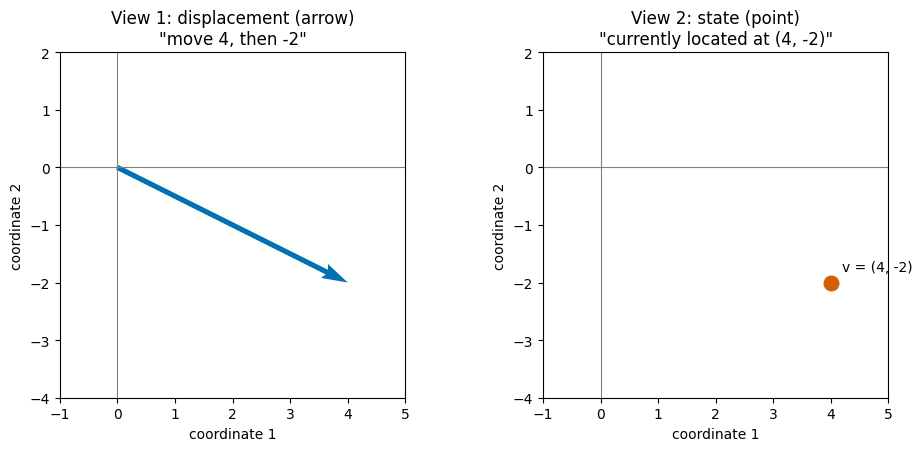

In [ ]:
# The same vector as an arrow (displacement) and as a point (state)
v = np.array([4.0, -2.0])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))

# Left: arrow view
ax = axes[0]
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color=PALETTE[0], width=0.015)
ax.set_xlim(-1, 5); ax.set_ylim(-4, 2)
ax.axhline(0, color='grey', lw=0.8); ax.axvline(0, color='grey', lw=0.8)
ax.set_aspect('equal')
ax.set_xlabel('coordinate 1'); ax.set_ylabel('coordinate 2')
ax.set_title('View 1: displacement (arrow)\n"move 4, then -2"')

# Right: point view
ax = axes[1]
ax.scatter([v[0]], [v[1]], color=PALETTE[1], s=110, marker='o', zorder=3)
ax.annotate('v = (4, -2)', (v[0], v[1]), textcoords="offset points", xytext=(8, 8))
ax.set_xlim(-1, 5); ax.set_ylim(-4, 2)
ax.axhline(0, color='grey', lw=0.8); ax.axvline(0, color='grey', lw=0.8)
ax.set_aspect('equal')
ax.set_xlabel('coordinate 1'); ax.set_ylabel('coordinate 2')
ax.set_title('View 2: state (point)\n"currently located at (4, -2)"')

plt.tight_layout()
plt.show()

#### Interactive version

In [ ]:

# INTERACTIVE VERSION -- the same vector as a displacement and as a state
fig_interactive = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        'View 1: displacement (arrow)<br>“move 4, then -2”',
        'View 2: state (point)<br>“currently located at (4, -2)”',
    ),
    horizontal_spacing=0.13,
)

# Arrow view: a line with a triangular tip.
fig_interactive.add_trace(go.Scatter(
    x=[0, v[0]], y=[0, v[1]], mode='lines+markers',
    line=dict(color=PALETTE[0], width=5),
    marker=dict(size=[1, 14], symbol=['circle', 'triangle-right'], color=PALETTE[0]),
    name='v as displacement',
    hovertemplate='(%{x:.1f}, %{y:.1f})<extra></extra>',
), row=1, col=1)

fig_interactive.add_trace(go.Scatter(
    x=[v[0]], y=[v[1]], mode='markers+text',
    text=['v = (4, -2)'], textposition='top right',
    marker=dict(size=14, color=PALETTE[1]),
    name='v as state',
    hovertemplate='State: (%{x:.1f}, %{y:.1f})<extra></extra>',
), row=1, col=2)

for col in (1, 2):
    fig_interactive.add_hline(y=0, line_width=1, line_color='grey', row=1, col=col)
    fig_interactive.add_vline(x=0, line_width=1, line_color='grey', row=1, col=col)
    fig_interactive.update_xaxes(range=[-1, 5], title_text='coordinate 1', scaleanchor=f'y{col if col > 1 else ""}', scaleratio=1, row=1, col=col)
    fig_interactive.update_yaxes(range=[-4, 2], title_text='coordinate 2', row=1, col=col)

fig_interactive.update_layout(
    title='The same vector, shown in two mathematically equivalent ways',
    template='plotly_white',
    width=980,
    height=500,
)
fig_interactive.show(config=PLOTLY_CONFIG)


# **Part 3: Vectors in NumPy**

Mathematicians usually represent a vector as a column:

$$\mathbf{v} = \begin{pmatrix} v_1 \\ v_2 \\ v_3 \end{pmatrix}$$

In NumPy, by contrast, the same vector is commonly represented with the shape `(n,)` — a flat,
one-dimensional array with no "row" or "column" orientation at all. This difference rarely
matters yet, but it will start to matter once matrices enter the picture (a later lesson), so
it is worth seeing now, while the vectors are still simple.

In [ ]:
neuron_labels = ['N1', 'N2', 'N3', 'N4', 'N5']
r = np.asarray([12.5, 45.3, 8.7, 33.1, 71.4])   # firing rates, spikes/s

print("Population vector r:", r)
print("shape:", r.shape, " ndim:", r.ndim, " size:", r.size, " dtype:", r.dtype)

print("\nEach coordinate, with its label and unit:")
for label, rate in zip(neuron_labels, r):
    print(f"  {label}: {rate:5.1f} spikes/s")

print("\nIndexing and slicing:")
print("r[0]     (first neuron)      :", r[0])
print("r[-1]    (last neuron)       :", r[-1])
print("r[1:3]   (neurons N2 and N3) :", r[1:3])

Population vector r: [12.5 45.3  8.7 33.1 71.4]
shape: (5,)  ndim: 1  size: 5  dtype: float64

Each coordinate, with its label and unit:
  N1:  12.5 spikes/s
  N2:  45.3 spikes/s
  N3:   8.7 spikes/s
  N4:  33.1 spikes/s
  N5:  71.4 spikes/s

Indexing and slicing:
r[0]     (first neuron)      : 12.5
r[-1]    (last neuron)       : 71.4
r[1:3]   (neurons N2 and N3) : [45.3  8.7]


### The shapes `(n,)`, `(n, 1)`, and `(1, n)` are different

`(n,)` is a flat vector.\
`(n, 1)` is a *column matrix* with one column.\
`(1, n)` is a *row matrix* with one row.

They can hold the exact same numbers and still behave differently, especially when combined with each other,
because of NumPy's **broadcasting** rules.

In [ ]:
v_flat = np.array([1.0, 2.0, 3.0])         # shape (3,)
v_col  = v_flat.reshape(3, 1)              # shape (3, 1) -- a column
v_row  = v_flat.reshape(1, 3)              # shape (1, 3) -- a row

print("v_flat:", v_flat.shape, "\n", v_flat)
print("\nv_col:", v_col.shape, "\n", v_col)
print("\nv_row:", v_row.shape, "\n", v_row)

v_flat: (3,) 
 [1. 2. 3.]

v_col: (3, 1) 
 [[1.]
 [2.]
 [3.]]

v_row: (1, 3) 
 [[1. 2. 3.]]


Here is exactly the kind of surprise these shape differences can cause. We *intend* to add
two copies of the same three numbers and expect another length-3 vector back.

In [ ]:
# BUG: adding a (3,) vector to a (3, 1) column does NOT give what you might expect.
buggy_result = v_flat + v_col
print("v_flat + v_col produced shape:", buggy_result.shape)
print(buggy_result)
print("\nThat is a 3x3 matrix, not a length-3 vector -- NumPy 'broadcast' the two shapes")
print("together element-by-element across both axes, instead of adding matching entries.")

# FIX: make sure both operands have the same shape before adding.
fixed_result = v_flat + v_col.reshape(-1)     # .reshape(-1) flattens back to (3,)
print("\nFixed: v_flat + v_col.reshape(-1) =", fixed_result, " shape:", fixed_result.shape)

v_flat + v_col produced shape: (3, 3)
[[2. 3. 4.]
 [3. 4. 5.]
 [4. 5. 6.]]

That is a 3x3 matrix, not a length-3 vector -- NumPy 'broadcast' the two shapes
together element-by-element across both axes, instead of adding matching entries.

Fixed: v_flat + v_col.reshape(-1) = [2. 4. 6.]  shape: (3,)


Before combining two arrays, check both `.shape`s. If they are not identical, reshape one of them first.

# **Part 4: Neural Population Vectors**

Let's build an example with **three neurons** recorded under **four experimental
conditions**: a quiet baseline, two different sensory stimuli, and a motor response. For each
condition we record several repeated trials (so we can see that repeated measurements of the
"same" condition still vary a little), plus a mean population vector that summarizes each
condition.

In [ ]:
# Four experimental conditions, three neurons, several trials each.
neuron_labels = ['N1', 'N2', 'N3']
condition_means = {
    'Baseline':   np.array([ 5.0,  8.0,  6.0]),
    'Stimulus A': np.array([55.0, 12.0,  9.0]),
    'Stimulus B': np.array([10.0, 60.0, 45.0]),
    'Motor':      np.array([28.0, 32.0, 60.0]),
}
n_trials = 15
trial_noise_sd = 4.0   # spikes/s -- trial-to-trial variability

condition_trials = {
    cond: mean + RNG.normal(0.0, trial_noise_sd, size=(n_trials, 3))
    for cond, mean in condition_means.items()
}

print("Mean population vector per condition (units: spikes/s):")
for cond, mean_vec in condition_means.items():
    print(f"  {cond:10s}: {mean_vec}  (N1={mean_vec[0]:.0f}, N2={mean_vec[1]:.0f}, N3={mean_vec[2]:.0f})")

Mean population vector per condition (units: spikes/s):
  Baseline  : [5. 8. 6.]  (N1=5, N2=8, N3=6)
  Stimulus A: [55. 12.  9.]  (N1=55, N2=12, N3=9)
  Stimulus B: [10. 60. 45.]  (N1=10, N2=60, N3=45)
  Motor     : [28. 32. 60.]  (N1=28, N2=32, N3=60)


Each coordinate of every one of these vectors means the same thing across conditions: the
first entry is always N1's firing rate, the second is always N2's, the third is always N3's.
**Coordinate order must stay consistent**.

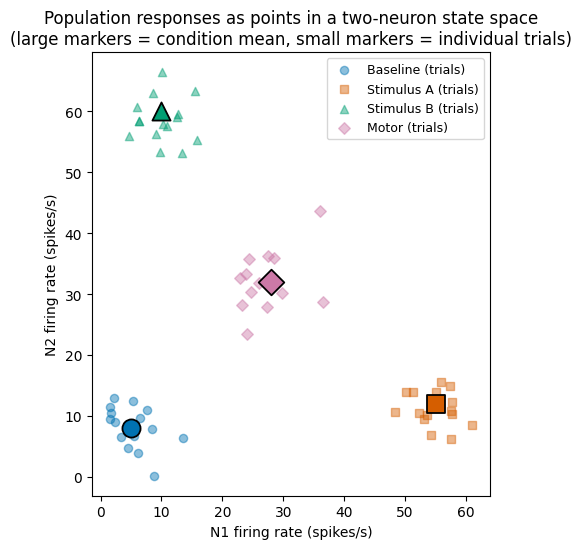

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 5.6))
for i, (cond, trials) in enumerate(condition_trials.items()):
    ax.scatter(trials[:, 0], trials[:, 1], color=PALETTE[i], marker=MARKERS[i], alpha=0.45, s=35, label=f'{cond} (trials)')
    mean_vec = condition_means[cond]
    ax.scatter(mean_vec[0], mean_vec[1], color=PALETTE[i], marker=MARKERS[i], edgecolor='black', linewidth=1.3, s=170, zorder=5)

ax.set_xlabel('N1 firing rate (spikes/s)')
ax.set_ylabel('N2 firing rate (spikes/s)')
ax.set_title('Population responses as points in a two-neuron state space\n(large markers = condition mean, small markers = individual trials)')
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

#### Interactive version

In [ ]:

fig_interactive = go.Figure()
for i_cond, (cond, trials) in enumerate(condition_trials.items()):
    fig_interactive.add_trace(go.Scatter(
        x=trials[:, 0],
        y=trials[:, 1],
        mode='markers',
        name=f'{cond} (trials)',
        marker=dict(color=PALETTE[i_cond], size=8, opacity=0.5, symbol=PLOTLY_MARKERS[i_cond]),
        customdata=np.arange(len(trials)),
        hovertemplate=(
            f'{cond}<br>trial %{{customdata}}<br>'
            'N1: %{x:.2f} spikes/s<br>N2: %{y:.2f} spikes/s<extra></extra>'
        ),
    ))
    mean_vec = condition_means[cond]
    fig_interactive.add_trace(go.Scatter(
        x=[mean_vec[0]],
        y=[mean_vec[1]],
        mode='markers+text',
        text=[f'{cond} mean'],
        textposition='top center',
        name=f'{cond} mean',
        marker=dict(color=PALETTE[i_cond], size=18, line=dict(color='black', width=2), symbol=PLOTLY_MARKERS[i_cond]),
        hovertemplate='N1 mean: %{x:.2f}<br>N2 mean: %{y:.2f}<extra></extra>',
    ))

fig_interactive.update_layout(
    title='Population responses in two-neuron state space<br><sup>Large markers = condition means</sup>',
    xaxis_title='N1 firing rate (spikes/s)',
    yaxis_title='N2 firing rate (spikes/s)',
    template='plotly_white',
    width=720,
    height=620,
    yaxis=dict(scaleanchor='x', scaleratio=1),
)
fig_interactive.show(config=PLOTLY_CONFIG)


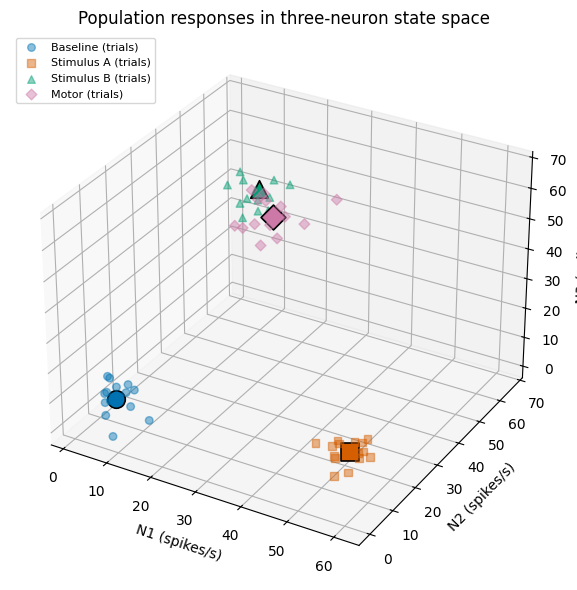

In [ ]:
# The same data with all three neurons, in 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
for i, (cond, trials) in enumerate(condition_trials.items()):
    ax.scatter(trials[:, 0], trials[:, 1], trials[:, 2], color=PALETTE[i],
               marker=MARKERS[i], alpha=0.45, s=30, label=f'{cond} (trials)')
    mean_vec = condition_means[cond]
    ax.scatter(mean_vec[0], mean_vec[1], mean_vec[2], color=PALETTE[i],
               marker=MARKERS[i], edgecolor='black', linewidth=1.2, s=160)

ax.set_xlabel('N1 (spikes/s)')
ax.set_ylabel('N2 (spikes/s)')
ax.set_zlabel('N3 (spikes/s)')
ax.set_title('Population responses in three-neuron state space')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

#### Interactive 3D version — drag to rotate

In [ ]:

fig_interactive = go.Figure()
for i_cond, (cond, trials) in enumerate(condition_trials.items()):
    fig_interactive.add_trace(go.Scatter3d(
        x=trials[:, 0], y=trials[:, 1], z=trials[:, 2],
        mode='markers',
        name=f'{cond} (trials)',
        marker=dict(color=PALETTE[i_cond], size=5, opacity=0.55, symbol='circle'),
        customdata=np.arange(len(trials)),
        hovertemplate=(
            f'{cond}<br>trial %{{customdata}}<br>'
            'N1: %{x:.2f}<br>N2: %{y:.2f}<br>N3: %{z:.2f}<extra></extra>'
        ),
    ))
    mean_vec = condition_means[cond]
    fig_interactive.add_trace(go.Scatter3d(
        x=[mean_vec[0]], y=[mean_vec[1]], z=[mean_vec[2]],
        mode='markers+text',
        text=[f'{cond} mean'],
        textposition='top center',
        name=f'{cond} mean',
        marker=dict(color=PALETTE[i_cond], size=10, line=dict(color='black', width=4)),
        hovertemplate='N1 mean: %{x:.2f}<br>N2 mean: %{y:.2f}<br>N3 mean: %{z:.2f}<extra></extra>',
    ))

fig_interactive.update_layout(
    title='Population responses in three-neuron state space',
    scene=dict(
        xaxis_title='N1 (spikes/s)',
        yaxis_title='N2 (spikes/s)',
        zaxis_title='N3 (spikes/s)',
        aspectmode='data',
    ),
    template='plotly_white',
    width=800,
    height=680,
)
fig_interactive.show(config=PLOTLY_CONFIG)


# **Part 5: Vector Addition, Subtraction, and Scalar Multiplication**

- **Addition** $\mathbf{u} + \mathbf{v}$: combine two vectors component-by-component.
- **Subtraction** $\mathbf{r}_2 - \mathbf{r}_1$: the **change** or **displacement** between
  two states.
- **Scalar multiplication** $\alpha \mathbf{v}$: every coordinate scaled by the same number
  $\alpha$. This can represent increasing or decreasing the *overall magnitude* of a response
  while keeping its relative pattern (shape) fixed.

In [ ]:
# Numeric example, tied to two of our conditions from Part 4
r_A = condition_means['Baseline']
r_B = condition_means['Stimulus A']

vector_sum   = r_A + r_B     # a modelled combination
delta_r      = r_B - r_A     # the change (displacement) from baseline to stimulus
scaled_r_A   = 1.5 * r_A     # baseline scaled up by 50% -- same pattern, larger magnitude

print("r_A (Baseline)  :", r_A, "spikes/s")
print("r_B (Stimulus A):", r_B, "spikes/s")
print("\nr_A + r_B  (modelled combination):", vector_sum)
print("r_B - r_A  (state change, delta_r):", delta_r)
print("1.5 * r_A  (same pattern, scaled magnitude):", scaled_r_A)

for i, label in enumerate(neuron_labels):
    direction = "increased" if delta_r[i] > 0 else ("decreased" if delta_r[i] < 0 else "did not change")
    print(f" \n {label}: {direction} by {abs(delta_r[i]):.1f} spikes/s going from Baseline to Stimulus A")

r_A (Baseline)  : [5. 8. 6.] spikes/s
r_B (Stimulus A): [55. 12.  9.] spikes/s

r_A + r_B  (modelled combination): [60. 20. 15.]
r_B - r_A  (state change, delta_r): [50.  4.  3.]
1.5 * r_A  (same pattern, scaled magnitude): [ 7.5 12.   9. ]
 
 N1: increased by 50.0 spikes/s going from Baseline to Stimulus A
 
 N2: increased by 4.0 spikes/s going from Baseline to Stimulus A
 
 N3: increased by 3.0 spikes/s going from Baseline to Stimulus A


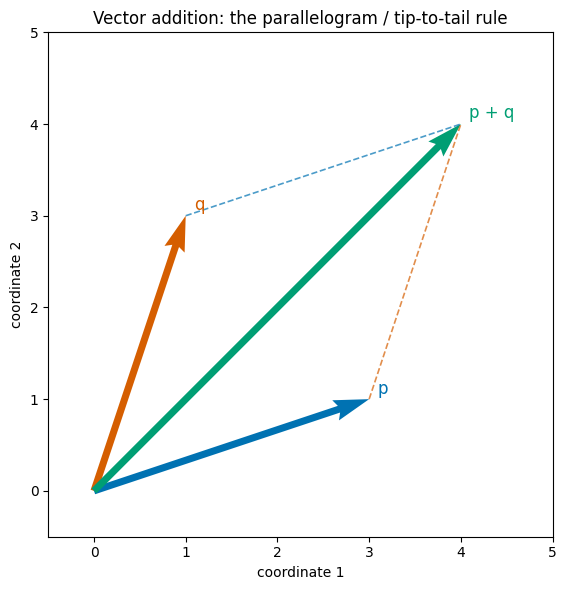

In [ ]:
# Geometric vector addition in 2D
p = np.array([3.0, 1.0])
q = np.array([1.0, 3.0])
s = p + q

fig, ax = plt.subplots(figsize=(6, 6))
qkw = dict(angles='xy', scale_units='xy', scale=1, width=0.014)
ax.quiver(0, 0, p[0], p[1], color=PALETTE[0], **qkw)
ax.quiver(0, 0, q[0], q[1], color=PALETTE[1], **qkw)
ax.quiver(0, 0, s[0], s[1], color=PALETTE[2], **qkw)

# "tip-to-tail" construction lines
ax.plot([p[0], s[0]], [p[1], s[1]], '--', color=PALETTE[1], lw=1.2, alpha=0.7)
ax.plot([q[0], s[0]], [q[1], s[1]], '--', color=PALETTE[0], lw=1.2, alpha=0.7)

ax.annotate('p', p, textcoords="offset points", xytext=(6, 4), color=PALETTE[0], fontsize=12)
ax.annotate('q', q, textcoords="offset points", xytext=(6, 4), color=PALETTE[1], fontsize=12)
ax.annotate('p + q', s, textcoords="offset points", xytext=(6, 4), color=PALETTE[2], fontsize=12)

ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 5)
ax.set_aspect('equal')
ax.set_xlabel('coordinate 1'); ax.set_ylabel('coordinate 2')
ax.set_title('Vector addition: the parallelogram / tip-to-tail rule')
plt.tight_layout()
plt.show()

#### Interactive version

In [ ]:

fig_interactive = go.Figure()

vector_specs = [
    ('p', np.array([0.0, 0.0]), p, PALETTE[0]),
    ('q', np.array([0.0, 0.0]), q, PALETTE[1]),
    ('p + q', np.array([0.0, 0.0]), s, PALETTE[2]),
]
for name, start, end, color in vector_specs:
    fig_interactive.add_trace(go.Scatter(
        x=[start[0], end[0]], y=[start[1], end[1]],
        mode='lines+markers+text',
        text=['', name], textposition='top right',
        line=dict(color=color, width=4),
        marker=dict(size=[1, 13], symbol=['circle', 'triangle-right'], color=color),
        name=name,
        hovertemplate=f'{name}: (%{{x:.1f}}, %{{y:.1f}})<extra></extra>',
    ))

fig_interactive.add_trace(go.Scatter(
    x=[p[0], s[0], None, q[0], s[0]],
    y=[p[1], s[1], None, q[1], s[1]],
    mode='lines',
    line=dict(color='grey', width=2, dash='dash'),
    name='tip-to-tail construction',
    hoverinfo='skip',
))

fig_interactive.update_layout(
    title='Vector addition: the parallelogram / tip-to-tail rule',
    xaxis=dict(title='coordinate 1', range=[-0.5, 5], scaleanchor='y', scaleratio=1),
    yaxis=dict(title='coordinate 2', range=[-0.5, 5]),
    template='plotly_white',
    width=650,
    height=620,
)
fig_interactive.show(config=PLOTLY_CONFIG)


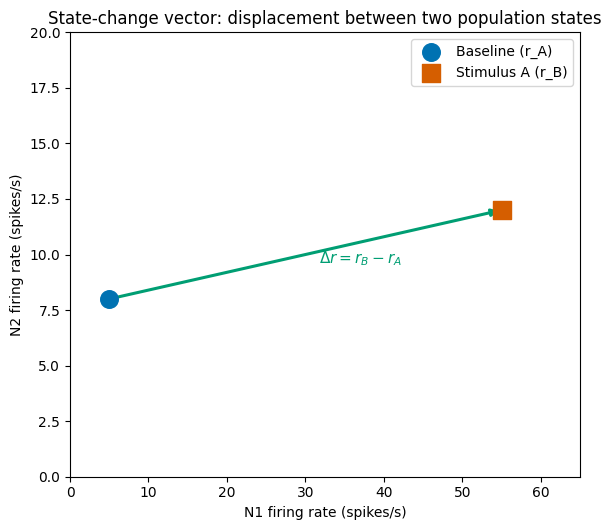

In [ ]:
# A state-change (displacement) vector between two neural conditions
fig, ax = plt.subplots(figsize=(6, 5.4))
ax.scatter(*r_A[:2], color=PALETTE[0], s=160, marker='o', zorder=5, label='Baseline (r_A)')
ax.scatter(*r_B[:2], color=PALETTE[1], s=160, marker='s', zorder=5, label='Stimulus A (r_B)')
ax.annotate('', xy=r_B[:2], xytext=r_A[:2], arrowprops=dict(arrowstyle='-|>', color=PALETTE[2], lw=2.2))
mid = (r_A[:2] + r_B[:2]) / 2
ax.annotate(r'$\Delta r = r_B - r_A$', mid, textcoords="offset points", xytext=(10, -6), color=PALETTE[2], fontsize=11)
ax.set_xlabel('N1 firing rate (spikes/s)')
ax.set_ylabel('N2 firing rate (spikes/s)')
ax.set_title('State-change vector: displacement between two population states')
ax.legend(loc='upper right')
ax.set_xlim(0, 65); ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()

#### Interactive version

In [ ]:
fig_interactive = go.Figure()
fig_interactive.add_trace(go.Scatter(
    x=[r_A[0]], y=[r_A[1]], mode='markers+text',
    text=['Baseline'], textposition='top center', name='Baseline (r_A)',
    marker=dict(color=PALETTE[0], size=18, line=dict(color='black', width=1)),
    hovertemplate='N1: %{x:.2f}<br>N2: %{y:.2f}<extra></extra>',
))
fig_interactive.add_trace(go.Scatter(
    x=[r_B[0]], y=[r_B[1]], mode='markers+text',
    text=['Stimulus A'], textposition='top center', name='Stimulus A (r_B)',
    marker=dict(color=PALETTE[1], size=18, symbol='square', line=dict(color='black', width=1)),
    hovertemplate='N1: %{x:.2f}<br>N2: %{y:.2f}<extra></extra>',
))
fig_interactive.add_annotation(
    x=r_B[0], y=r_B[1], ax=r_A[0], ay=r_A[1],
    xref='x', yref='y', axref='x', ayref='y',
    text='Δr = r_B − r_A', showarrow=True, arrowhead=5,
    arrowwidth=3, arrowcolor=PALETTE[2], font=dict(color=PALETTE[2]),
)
fig_interactive.update_layout(
    title='State-change vector: displacement between two population states',
    xaxis=dict(title='N1 firing rate (spikes/s)', range=[0, 65]),
    yaxis=dict(title='N2 firing rate (spikes/s)', range=[0, 20]),
    template='plotly_white', width=700, height=570,
)
fig_interactive.show(config=PLOTLY_CONFIG)


# **Part 6: Norm, Magnitude, and Distance**

The **Euclidean norm** (magnitude, or length) of a vector $\mathbf{v} = (v_1, \dots, v_n)$ is

$$\|\mathbf{v}\|_2 = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$$

The **Euclidean distance** between two vectors is the magnitude of their difference:

$$d(\mathbf{u}, \mathbf{v}) = \|\mathbf{u} - \mathbf{v}\|_2$$

i.e. exactly the length of the displacement arrow from Part 5.

In [ ]:
# Manual calculation for a small, classic vector, then verified with NumPy
v_small = np.array([3.0, 4.0])

norm_manual = np.sqrt(np.sum(v_small ** 2))
norm_numpy  = np.linalg.norm(v_small)

print(f"v = {v_small}")
print(f"Manual:  sqrt(3^2 + 4^2) = sqrt({3.0**2} + {4.0**2}) = sqrt({3.0**2 + 4.0**2}) = {norm_manual}")
print(f"NumPy:   np.linalg.norm(v) = {norm_numpy}")
print(f"Match?   {np.isclose(norm_manual, norm_numpy)}")

v = [3. 4.]
Manual:  sqrt(3^2 + 4^2) = sqrt(9.0 + 16.0) = sqrt(25.0) = 5.0
NumPy:   np.linalg.norm(v) = 5.0
Match?   True


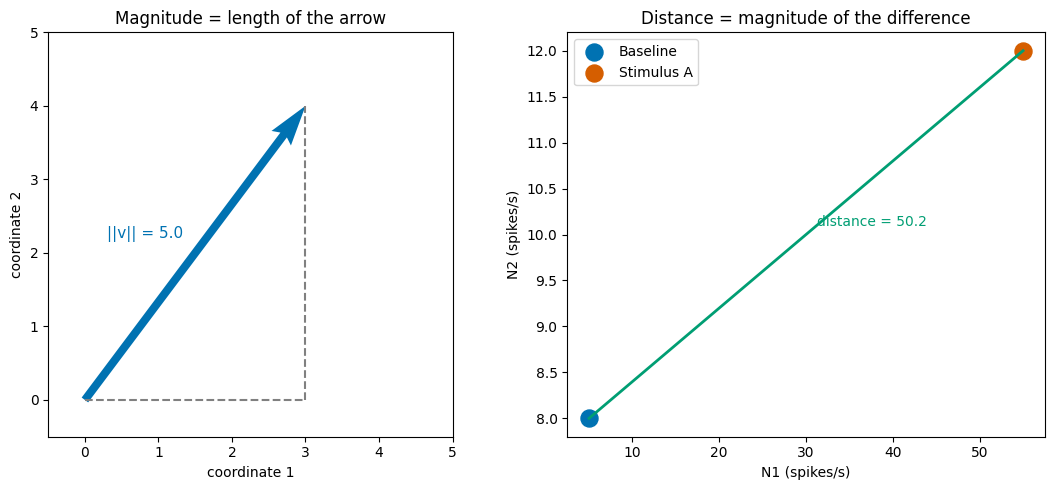

In [ ]:
# Mgnitude as the hypotenuse of a right triangle, and distance as a length
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
ax.quiver(0, 0, v_small[0], v_small[1], angles='xy', scale_units='xy', scale=1, color=PALETTE[0], width=0.02)
ax.plot([0, v_small[0]], [0, 0], '--', color='grey')
ax.plot([v_small[0], v_small[0]], [0, v_small[1]], '--', color='grey')
ax.annotate(f'||v|| = {norm_numpy:.1f}', (0.3, 2.2), color=PALETTE[0], fontsize=11)
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 5); ax.set_aspect('equal')
ax.set_xlabel('coordinate 1'); ax.set_ylabel('coordinate 2')
ax.set_title('Magnitude = length of the arrow')

ax = axes[1]
u_state, w_state = condition_means['Baseline'][:2], condition_means['Stimulus A'][:2]
dist = np.linalg.norm(w_state - u_state)
ax.scatter(*u_state, color=PALETTE[0], s=150, label='Baseline')
ax.scatter(*w_state, color=PALETTE[1], s=150, label='Stimulus A')
ax.plot([u_state[0], w_state[0]], [u_state[1], w_state[1]], '-', color=PALETTE[2], lw=2)
mid = (u_state + w_state) / 2
ax.annotate(f'distance = {dist:.1f}', mid, textcoords="offset points", xytext=(8, 6), color=PALETTE[2])
ax.set_xlabel('N1 (spikes/s)'); ax.set_ylabel('N2 (spikes/s)')
ax.set_title('Distance = magnitude of the difference')
ax.legend()

plt.tight_layout()
plt.show()

#### Interactive version

In [ ]:
fig_interactive = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Magnitude = length of the arrow',
        'Distance = magnitude of the difference',
    ),
    horizontal_spacing=0.16,
)

fig_interactive.add_trace(go.Scatter(
    x=[0, v_small[0]], y=[0, v_small[1]],
    mode='lines+markers', name='v',
    line=dict(color=PALETTE[0], width=4),
    marker=dict(size=[1, 13], symbol=['circle', 'triangle-right'], color=PALETTE[0]),
    hovertemplate='(%{x:.1f}, %{y:.1f})<extra></extra>',
), row=1, col=1)
fig_interactive.add_trace(go.Scatter(
    x=[0, v_small[0], v_small[0]], y=[0, 0, v_small[1]],
    mode='lines', name='right-triangle legs',
    line=dict(color='grey', dash='dash'), hoverinfo='skip',
), row=1, col=1)
fig_interactive.add_annotation(
    x=1.7, y=2.4, text=f'||v|| = {norm_numpy:.1f}', showarrow=False,
    font=dict(color=PALETTE[0]), xref='x', yref='y',
)

fig_interactive.add_trace(go.Scatter(
    x=[u_state[0]], y=[u_state[1]], mode='markers', name='Baseline',
    marker=dict(color=PALETTE[0], size=16),
    hovertemplate='Baseline<br>N1: %{x:.2f}<br>N2: %{y:.2f}<extra></extra>',
), row=1, col=2)
fig_interactive.add_trace(go.Scatter(
    x=[w_state[0]], y=[w_state[1]], mode='markers', name='Stimulus A',
    marker=dict(color=PALETTE[1], size=16),
    hovertemplate='Stimulus A<br>N1: %{x:.2f}<br>N2: %{y:.2f}<extra></extra>',
), row=1, col=2)
fig_interactive.add_trace(go.Scatter(
    x=[u_state[0], w_state[0]], y=[u_state[1], w_state[1]],
    mode='lines', name=f'distance = {dist:.1f}',
    line=dict(color=PALETTE[2], width=4),
    hovertemplate=f'distance = {dist:.2f}<extra></extra>',
), row=1, col=2)

fig_interactive.update_xaxes(title_text='coordinate 1', range=[-0.5, 5], scaleanchor='y', scaleratio=1, row=1, col=1)
fig_interactive.update_yaxes(title_text='coordinate 2', range=[-0.5, 5], row=1, col=1)
fig_interactive.update_xaxes(title_text='N1 (spikes/s)', row=1, col=2)
fig_interactive.update_yaxes(title_text='N2 (spikes/s)', row=1, col=2)
fig_interactive.update_layout(template='plotly_white', width=1050, height=550)
fig_interactive.show(config=PLOTLY_CONFIG)


In [ ]:
# Pairwise distances between all four condition means
conditions = list(condition_means.keys())
print(f"{'':12s}" + "".join(f"{c:>12s}" for c in conditions))
for c1 in conditions:
    row = f"{c1:12s}"
    for c2 in conditions:
        d = np.linalg.norm(condition_means[c1] - condition_means[c2])
        row += f"{d:12.1f}"
    print(row)
print("\n(All distances in spikes/s, computed across all three neurons.)")

                Baseline  Stimulus A  Stimulus B       Motor
Baseline             0.0        50.2        65.2        63.4
Stimulus A          50.2         0.0        75.0        61.1
Stimulus B          65.2        75.0         0.0        36.5
Motor               63.4        61.1        36.5         0.0

(All distances in spikes/s, computed across all three neurons.)


**Interpretation:** The table lets us compare *every* pair of conditions at once. Distances close to zero suggest the two conditions evoked numerically similar population patterns; large distances suggest very different patterns.

**Limitations of Euclidean distance.** This measurement quietly assumes every neuron's firing-rate axis is directly comparable to every other's. That assumption can fail:

- Coordinates may be measured in **different units** entirely (a neuron's firing rate in Hz
  next to an ML feature measured in different physical units).
- Neurons can have very **different firing-rate ranges**: a neuron that fires at
  0–200 spikes/s will dominate a Euclidean distance next to a neuron that only varies
  between 0–5 spikes/s, simply because its numbers are bigger.
- The same issue affects ML feature vectors: a feature measured in the thousands (e.g. house
  size in square feet) will dominate a feature measured in single digits (e.g. number of
  bedrooms) unless the features are rescaled.
- Distance also depends on **preprocessing and representation** — smoothing, normalization,
  or a different choice of coordinates can all change the numeric distance without changing
  the underlying biology.

We are not claiming Euclidean distance is meaningless — only that it is a **modelling
choice**, not an automatic measure of biological or perceptual similarity. Feature scaling
and alternative distance measures are topics for a later lesson.

# **Part 7: Unit Vectors and Direction**

Sometimes the *pattern* of a response matters more than its overall *strength*. A **unit
vector** keeps a vector's direction but forces its length to exactly 1:

$$\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|_2}, \qquad \mathbf{v} \neq \mathbf{0}$$

This operation is called **normalisation**.

The zero vector has no defined direction, so it cannot be
normalised; dividing by a norm of zero is undefined, and any robust implementation must
guard against it explicitly.

In [ ]:
def normalise(v, eps=1e-12):
    """Return the unit vector of v (direction only, magnitude forced to 1).

    Raises ValueError if v is (numerically) the zero vector, since the zero
    vector has no defined direction.
    """
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm < eps:
        raise ValueError("The zero vector has no defined direction.")
    return v / norm


# Demonstrate on a nonzero vector
v_demo = np.array([3.0, 4.0])
v_hat = normalise(v_demo)
print("v      :", v_demo, " ||v|| =", np.linalg.norm(v_demo))
print("v_hat  :", v_hat, " ||v_hat|| =", np.linalg.norm(v_hat))

# Safe handling of the zero vector
try:
    normalise(np.zeros(3))
except ValueError as e:
    print("\nAttempted to normalise the zero vector -- caught safely:")
    print(" ", e)

v      : [3. 4.]  ||v|| = 5.0
v_hat  : [0.6 0.8]  ||v_hat|| = 1.0

Attempted to normalise the zero vector -- caught safely:
  The zero vector has no defined direction.


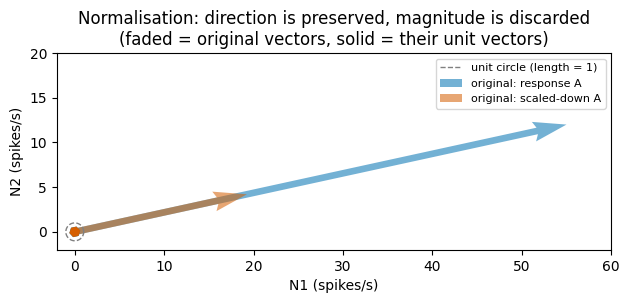

In [ ]:
# Normalisation comparison: what changes, what stays the same
theta_grid = np.linspace(0, 2 * np.pi, 200)
unit_circle_x, unit_circle_y = np.cos(theta_grid), np.sin(theta_grid)

response_a = condition_means['Stimulus A'][:2]      # a "strong, large" response pattern
response_b = 0.35 * response_a                      # the SAME direction, weaker overall

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.plot(unit_circle_x, unit_circle_y, '--', color='grey', lw=1, label='unit circle (length = 1)')

for vec, color, label in [(response_a, PALETTE[0], 'original: response A'),
                           (response_b, PALETTE[1], 'original: scaled-down A')]:
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1,
              color=color, width=0.012, alpha=0.55, label=label)
    v_hat = normalise(vec)
    ax.quiver(0, 0, v_hat[0], v_hat[1], angles='xy', scale_units='xy', scale=1,
              color=color, width=0.02)

ax.set_xlim(-2, 60); ax.set_ylim(-2, 20)
ax.set_aspect('equal')
ax.set_xlabel('N1 (spikes/s)'); ax.set_ylabel('N2 (spikes/s)')
ax.set_title('Normalisation: direction is preserved, magnitude is discarded\n(faded = original vectors, solid = their unit vectors)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

Both original vectors point the same direction, so both normalise to the SAME unit.\
Vector -- normalising removes information about overall response strength, keeping only the relative pattern across neurons.

#### Interactive version

In [ ]:

fig_interactive = go.Figure()
fig_interactive.add_trace(go.Scatter(
    x=unit_circle_x, y=unit_circle_y, mode='lines', name='unit circle (length = 1)',
    line=dict(color='grey', dash='dash'), hoverinfo='skip',
))

for vec, color, label in [
    (response_a, PALETTE[0], 'original: response A'),
    (response_b, PALETTE[1], 'original: scaled-down A'),
]:
    v_hat = normalise(vec)
    fig_interactive.add_trace(go.Scatter(
        x=[0, vec[0]], y=[0, vec[1]], mode='lines+markers', name=label,
        line=dict(color=color, width=4), opacity=0.5,
        marker=dict(size=[1, 11], symbol=['circle', 'triangle-right'], color=color),
        hovertemplate=f'{label}<br>(%{{x:.3f}}, %{{y:.3f}})<extra></extra>',
    ))
    fig_interactive.add_trace(go.Scatter(
        x=[0, v_hat[0]], y=[0, v_hat[1]], mode='lines+markers', name=f'unit vector: {label}',
        line=dict(color=color, width=7),
        marker=dict(size=[1, 12], symbol=['circle', 'triangle-right'], color=color),
        hovertemplate='unit vector<br>(%{x:.3f}, %{y:.3f})<extra></extra>',
    ))

fig_interactive.update_layout(
    title='Normalisation: direction is preserved, magnitude is discarded',
    xaxis=dict(title='N1 (spikes/s)', range=[-2, 60], scaleanchor='y', scaleratio=1),
    yaxis=dict(title='N2 (spikes/s)', range=[-2, 20]),
    template='plotly_white', width=730, height=680,
)
fig_interactive.show(config=PLOTLY_CONFIG)


**What normalisation removes:** the overall magnitude (how strongly the population responded).

**What it keeps:** the relative pattern across neurons — which neurons fired
more than others.

# **Part 8: Linear Combinations, Span, Basis, and Coordinates**

A **linear combination** of vectors is a weighted sum: $\alpha_1 \mathbf{v}_1 + \alpha_2 \mathbf{v}_2 + \cdots$.\
The **standard basis** vectors in 2D, $\mathbf{e}_1 = (1, 0)$ and
$\mathbf{e}_2 = (0, 1)$, are the simplest possible building blocks: *any* 2D vector can be rebuilt as a linear combination of just these two.

In [ ]:
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

v = np.array([4.0, -2.0])
alpha1, alpha2 = v[0], v[1]          # the coordinates of v ARE the weights needed
reconstructed = alpha1 * e1 + alpha2 * e2

print("e1 =", e1, "  e2 =", e2)
print(f"v = {v} = {alpha1} * e1 + {alpha2} * e2 = {reconstructed}")
print("Reconstruction matches v?", np.allclose(reconstructed, v))

e1 = [1. 0.]   e2 = [0. 1.]
v = [ 4. -2.] = 4.0 * e1 + -2.0 * e2 = [ 4. -2.]
Reconstruction matches v? True


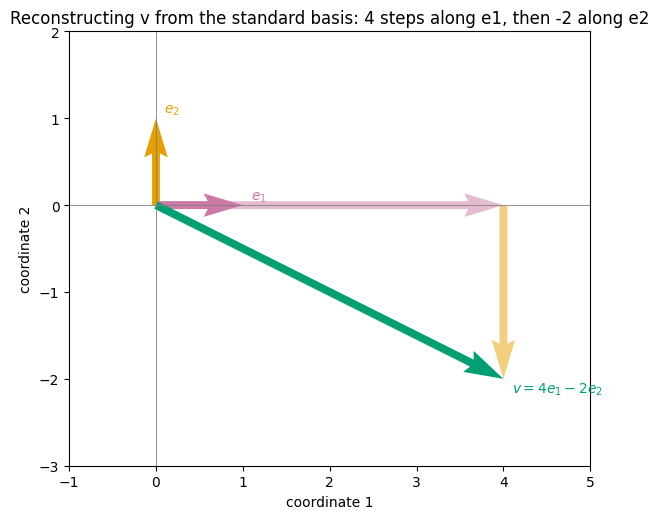

In [ ]:
# VISUALIZATION -- basis vectors and a linear-combination reconstruction
fig, ax = plt.subplots(figsize=(6.2, 6.2))
qkw = dict(angles='xy', scale_units='xy', scale=1, width=0.015)
ax.quiver(0, 0, e1[0], e1[1], color=PALETTE[3], **qkw)
ax.quiver(0, 0, e2[0], e2[1], color=PALETTE[4], **qkw)
ax.quiver(0, 0, alpha1 * e1[0], alpha1 * e1[1], color=PALETTE[3], alpha=0.5, **qkw)
ax.quiver(alpha1 * e1[0], alpha1 * e1[1], alpha2 * e2[0], alpha2 * e2[1], color=PALETTE[4], alpha=0.5, **qkw)
ax.quiver(0, 0, v[0], v[1], color=PALETTE[2], **qkw)

ax.annotate(r'$e_1$', e1, textcoords="offset points", xytext=(6, 4), color=PALETTE[3])
ax.annotate(r'$e_2$', e2, textcoords="offset points", xytext=(6, 4), color=PALETTE[4])
ax.annotate(r'$v = 4e_1 - 2e_2$', v, textcoords="offset points", xytext=(6, -10), color=PALETTE[2])

ax.set_xlim(-1, 5); ax.set_ylim(-3, 2)
ax.axhline(0, color='grey', lw=0.6); ax.axvline(0, color='grey', lw=0.6)
ax.set_aspect('equal')
ax.set_xlabel('coordinate 1'); ax.set_ylabel('coordinate 2')
ax.set_title('Reconstructing v from the standard basis: 4 steps along e1, then -2 along e2')
plt.tight_layout()
plt.show()

#### Interactive version

In [ ]:
fig_interactive = go.Figure()
segments = [
    ('e1', np.array([0.0, 0.0]), e1, PALETTE[3], 5, 1.0),
    ('e2', np.array([0.0, 0.0]), e2, PALETTE[4], 5, 1.0),
    ('4e1', np.array([0.0, 0.0]), alpha1 * e1, PALETTE[3], 4, 0.45),
    ('−2e2 from 4e1', alpha1 * e1, v, PALETTE[4], 4, 0.45),
    ('v = 4e1 − 2e2', np.array([0.0, 0.0]), v, PALETTE[2], 6, 1.0),
]
for name, start, end, color, width, opacity in segments:
    fig_interactive.add_trace(go.Scatter(
        x=[start[0], end[0]], y=[start[1], end[1]],
        mode='lines+markers', name=name, opacity=opacity,
        line=dict(color=color, width=width),
        marker=dict(size=[1, 12], symbol=['circle', 'triangle-right'], color=color),
        hovertemplate=f'{name}<br>(%{{x:.2f}}, %{{y:.2f}})<extra></extra>',
    ))

fig_interactive.add_hline(y=0, line_color='grey', line_width=1)
fig_interactive.add_vline(x=0, line_color='grey', line_width=1)
fig_interactive.update_layout(
    title='Reconstructing v from the standard basis',
    xaxis=dict(title='coordinate 1', range=[-1, 5], scaleanchor='y', scaleratio=1),
    yaxis=dict(title='coordinate 2', range=[-3, 2]),
    template='plotly_white', width=700, height=650,
)
fig_interactive.show(config=PLOTLY_CONFIG)


**Neuroscience Context:** suppose two coordinated response *patterns*
(directions) are common building blocks of population activity —
$\mathbf{u}_{\text{stim}} = (1, 1, 0)$ (a "sensory-driven" pattern) and
$\mathbf{u}_{\text{motor}} = (0, 1, 1)$ (a "motor-driven" pattern). A given population state
can then be described as a linear combination of these two directions.

In [ ]:
u_stim  = np.array([1.0, 1.0, 0.0])
u_motor = np.array([0.0, 1.0, 1.0])

a, b = 20.0, 15.0    # how strongly each pattern is engaged on this trial
combined_state = a * u_stim + b * u_motor
print(f"{a} * u_stim + {b} * u_motor = {combined_state}")

20.0 * u_stim + 15.0 * u_motor = [20. 35. 15.]


**The span** of a set of vectors is the *entire collection of points reachable* by every
possible choice of weights. Two vectors that point in different directions
(**linearly independent**) span an entire plane; two vectors that point along the same line
(**linearly dependent** — one is a scalar multiple of the other) only ever reach that single
line, no matter how you weight them.

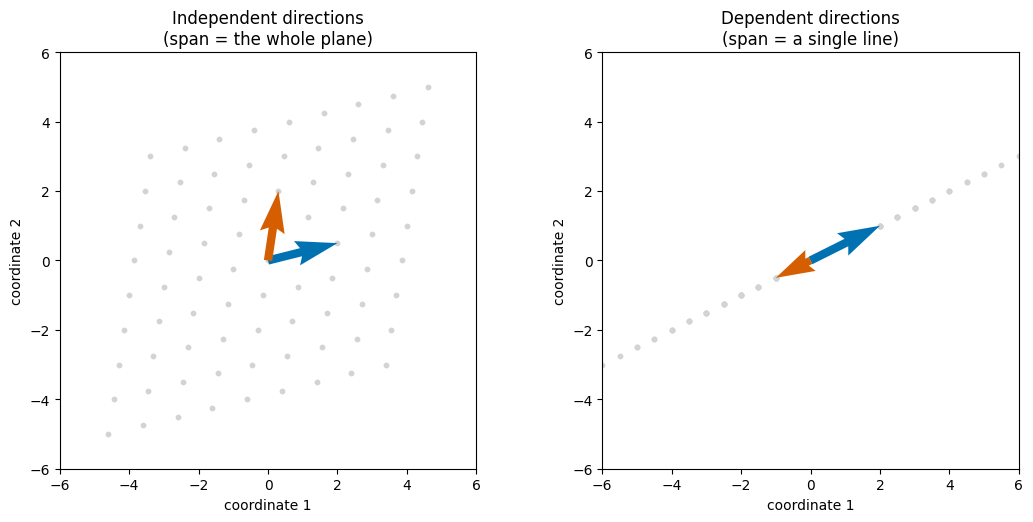

In [ ]:
# Independent vs. dependent directions -- span collapses from a plane to a line
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
coeffs = np.linspace(-2, 2, 9)

v1_indep, v2_indep = np.array([2.0, 0.5]), np.array([0.3, 2.0])
v1_dep,   v2_dep   = np.array([2.0, 1.0]), np.array([-1.0, -0.5])   # v2_dep = -0.5 * v1_dep

for ax, v1, v2, title in [
    (axes[0], v1_indep, v2_indep, 'Independent directions\n(span = the whole plane)'),
    (axes[1], v1_dep,   v2_dep,   'Dependent directions\n(span = a single line)'),
]:
    pts = np.array([[a1 * v1 + a2 * v2 for a2 in coeffs] for a1 in coeffs]).reshape(-1, 2)
    ax.scatter(pts[:, 0], pts[:, 1], color='lightgrey', s=10, zorder=1)
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color=PALETTE[0], width=0.02, zorder=3)
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color=PALETTE[1], width=0.02, zorder=3)
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6); ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('coordinate 1'); ax.set_ylabel('coordinate 2')

plt.tight_layout()
plt.show()

#### Interactive version

In [ ]:
fig_interactive = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Independent directions<br>(span = the whole plane)',
        'Dependent directions<br>(span = a single line)',
    ),
    horizontal_spacing=0.12,
)

for col, (v1, v2) in enumerate([
    (v1_indep, v2_indep),
    (v1_dep, v2_dep),
], start=1):
    pts = np.array([[a1 * v1 + a2 * v2 for a2 in coeffs] for a1 in coeffs]).reshape(-1, 2)
    fig_interactive.add_trace(go.Scatter(
        x=pts[:, 0], y=pts[:, 1], mode='markers',
        name=f'span samples ({col})', showlegend=False,
        marker=dict(color='lightgrey', size=6),
        hovertemplate='(%{x:.2f}, %{y:.2f})<extra></extra>',
    ), row=1, col=col)
    for label, vec, color in [('v1', v1, PALETTE[0]), ('v2', v2, PALETTE[1])]:
        fig_interactive.add_trace(go.Scatter(
            x=[0, vec[0]], y=[0, vec[1]], mode='lines+markers',
            name=f'{label} ({"independent" if col == 1 else "dependent"})',
            line=dict(color=color, width=5),
            marker=dict(size=[1, 13], symbol=['circle', 'triangle-right'], color=color),
            hovertemplate=f'{label}: (%{{x:.2f}}, %{{y:.2f}})<extra></extra>',
        ), row=1, col=col)
    fig_interactive.update_xaxes(range=[-6, 6], title_text='coordinate 1', row=1, col=col)
    fig_interactive.update_yaxes(range=[-6, 6], title_text='coordinate 2', scaleanchor=f'x{col if col > 1 else ""}', scaleratio=1, row=1, col=col)

fig_interactive.update_layout(template='plotly_white', width=1050, height=560)
fig_interactive.show(config=PLOTLY_CONFIG)


# **Part 9: From Time Series to Neural State-Space Trajectories**

So far every population vector has represented a single moment. Real recordings track
activity **continuously through time**. At each time $t$, the population has a state vector
$\mathbf{r}(t)$; the ordered sequence of these state vectors is a **trajectory**.

**Example:** three neurons recorded for 3 seconds, with a
stimulus turning on partway through.

In [ ]:
# A reproducible time-varying, three-neuron population recording
dt = 0.05                                   # seconds per time bin
n_bins = 60
time_axis = np.arange(n_bins) * dt          # 0.00, 0.05, ..., 2.95 seconds
stim_onset_bin = 20                         # stimulus turns on at t = 1.00 s

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

ramp = sigmoid((np.arange(n_bins) - stim_onset_bin) / 3.0)   # 0 before onset, ~1 after

n1_trace = 5.0  + 45.0 * ramp                                # ramps up after stimulus onset
n2_trace = 10.0 + 8.0 * np.sin(2 * np.pi * time_axis / 1.5)  # slow oscillation throughout
n3_trace = 8.0  + 40.0 * ramp * (1 - 0.5 * ramp)             # rises then partially settles

noise = RNG.normal(0.0, 1.5, size=(n_bins, 3))
population_recording = np.stack([n1_trace, n2_trace, n3_trace], axis=1) + noise
population_recording = np.clip(population_recording, 0, None)  # firing rates cannot be negative

print("population_recording shape:", population_recording.shape, " (n_bins, n_neurons)")

population_recording shape: (60, 3)  (n_bins, n_neurons)


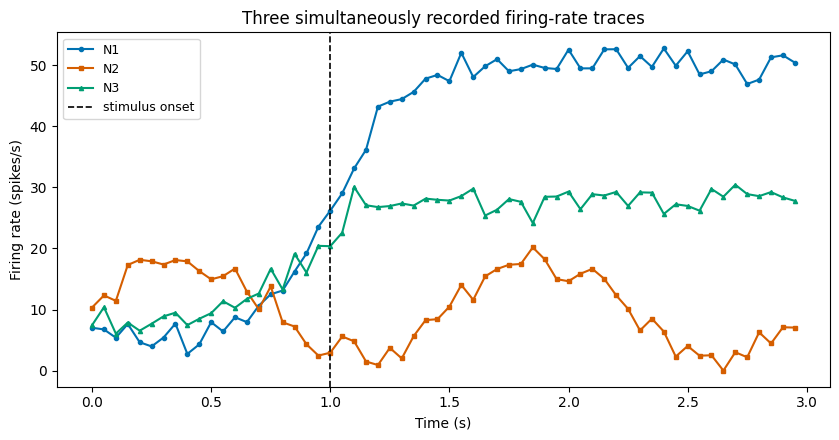

In [ ]:
# Individual firing-rate traces over time
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for i, label in enumerate(neuron_labels):
    ax.plot(time_axis, population_recording[:, i], color=PALETTE[i], marker=MARKERS[i], markersize=3, linewidth=1.5, label=label)
ax.axvline(time_axis[stim_onset_bin], color='black', linestyle='--', linewidth=1.2, label='stimulus onset')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Firing rate (spikes/s)')
ax.set_title('Three simultaneously recorded firing-rate traces')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

#### Interactive version

In [ ]:
fig_interactive = go.Figure()
for i_neuron, label in enumerate(neuron_labels):
    fig_interactive.add_trace(go.Scatter(
        x=time_axis,
        y=population_recording[:, i_neuron],
        mode='lines+markers',
        name=label,
        line=dict(color=PALETTE[i_neuron], width=2),
        marker=dict(size=5, symbol=PLOTLY_MARKERS[i_neuron]),
        hovertemplate=(
            f'{label}<br>time: %{{x:.2f}} s<br>'
            'rate: %{y:.2f} spikes/s<extra></extra>'
        ),
    ))
fig_interactive.add_vline(
    x=time_axis[stim_onset_bin],
    line_color='black', line_dash='dash', line_width=2,
    annotation_text='stimulus onset', annotation_position='top right',
)
fig_interactive.update_layout(
    title='Three simultaneously recorded firing-rate traces',
    xaxis_title='Time (s)',
    yaxis_title='Firing rate (spikes/s)',
    template='plotly_white',
    width=900,
    height=500,
    hovermode='x unified',
)
fig_interactive.show(config=PLOTLY_CONFIG)


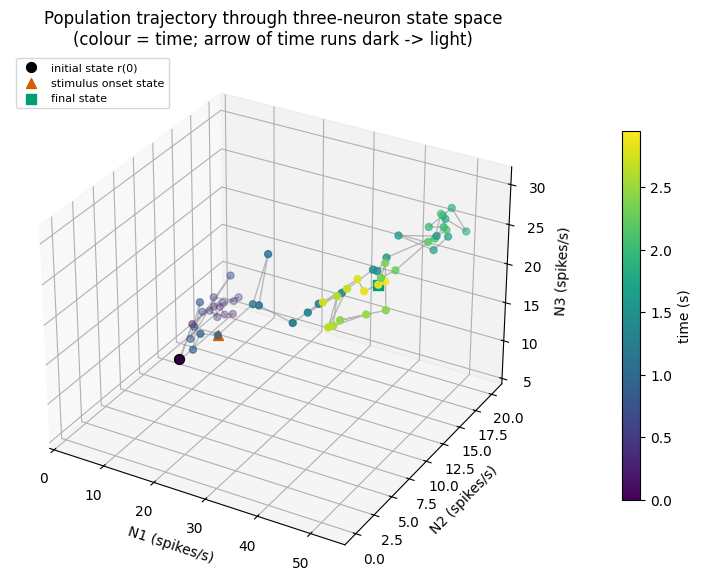

In [ ]:
# The corresponding time-ordered population trajectory (3D state space)
fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection='3d')

traj = population_recording
sc = ax.scatter(traj[:, 0], traj[:, 1], traj[:, 2], c=time_axis, cmap='viridis', s=25)
ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color='grey', alpha=0.5, linewidth=1)

initial, final, mid = traj[0], traj[-1], traj[stim_onset_bin]
ax.scatter(*initial, color='black', marker='o', s=50, label='initial state r(0)')
ax.scatter(*mid, color=PALETTE[1], marker='^', s=50, label='stimulus onset state')
ax.scatter(*final, color=PALETTE[2], marker='s', s=50, label='final state')

ax.set_xlabel('N1 (spikes/s)'); ax.set_ylabel('N2 (spikes/s)'); ax.set_zlabel('N3 (spikes/s)')
ax.set_title('Population trajectory through three-neuron state space\n(colour = time; arrow of time runs dark -> light)')
ax.legend(loc='upper left', fontsize=8)
fig.colorbar(sc, ax=ax, shrink=0.6, label='time (s)', pad=0.12)
plt.tight_layout()
plt.show()


#### Interactive 3D version and trajectory animation

The first figure is freely rotatable. The second figure has **Play**, **Pause**, and a time
slider. The Matplotlib cell below it creates the same movement as a conventional MP4 video.


In [ ]:
# INTERACTIVE VERSION -- rotatable 3D trajectory
traj = population_recording
initial, final, mid = traj[0], traj[-1], traj[stim_onset_bin]

fig_interactive = go.Figure()
fig_interactive.add_trace(go.Scatter3d(
    x=traj[:, 0], y=traj[:, 1], z=traj[:, 2],
    mode='lines+markers',
    name='population trajectory',
    line=dict(color='grey', width=3),
    marker=dict(
        size=5,
        color=time_axis,
        colorscale='Viridis',
        colorbar=dict(title='time (s)'),
        showscale=True,
    ),
    customdata=time_axis,
    hovertemplate=(
        'time: %{customdata:.2f} s<br>'
        'N1: %{x:.2f}<br>N2: %{y:.2f}<br>N3: %{z:.2f}<extra></extra>'
    ),
))
# for state, color, symbol, label in [
#     (initial, 'black', 'circle', 'initial state r(0)'),
#     (mid, PALETTE[1], 'diamond', 'stimulus onset state'),
#     (final, PALETTE[2], 'square', 'final state'),
# ]:
#     fig_interactive.add_trace(go.Scatter3d(
#         x=[state[0]], y=[state[1]], z=[state[2]],
#         mode='markers', name=label,
#         marker=dict(color=color, size=9, symbol=symbol),
#         hovertemplate=f'{label}<br>N1: %{{x:.2f}}<br>N2: %{{y:.2f}}<br>N3: %{{z:.2f}}<extra></extra>',
#     ))
fig_interactive.update_layout(
    title='Population trajectory through three-neuron state space',
    scene=dict(
        xaxis_title='N1 (spikes/s)',
        yaxis_title='N2 (spikes/s)',
        zaxis_title='N3 (spikes/s)',
        aspectmode='data',
    ),
    template='plotly_white',
    width=850,
    height=700,
)
fig_interactive.show(config=PLOTLY_CONFIG)


In [ ]:

# INTERACTIVE ANIMATION -- Plotly play/pause trajectory reveal
frame_indices = list(range(len(traj)))

fig_trajectory_animation = go.Figure(
    data=[
        # Faint full route provides spatial context.
        go.Scatter3d(
            x=traj[:, 0], y=traj[:, 1], z=traj[:, 2],
            mode='lines', line=dict(color='lightgrey', width=2),
            name='complete route', hoverinfo='skip',
        ),
        # Revealed route; frame 0 starts with the initial state only.
        go.Scatter3d(
            x=traj[:1, 0], y=traj[:1, 1], z=traj[:1, 2],
            mode='lines+markers',
            line=dict(color='grey', width=5),
            marker=dict(size=5, color=time_axis[:1], colorscale='Viridis', cmin=time_axis.min(), cmax=time_axis.max()),
            name='trajectory so far',
        ),
        go.Scatter3d(
            x=[traj[0, 0]], y=[traj[0, 1]], z=[traj[0, 2]],
            mode='markers', marker=dict(color='white', size=10, line=dict(color='black', width=4)),
            name='current state',
        ),
        go.Scatter3d(
            x=[initial[0]], y=[initial[1]], z=[initial[2]],
            mode='markers', marker=dict(color='black', size=8), name='initial state r(0)',
        ),
        go.Scatter3d(
            x=[mid[0]], y=[mid[1]], z=[mid[2]],
            mode='markers', marker=dict(color=PALETTE[1], size=9, symbol='diamond'), name='stimulus onset state',
        ),
        go.Scatter3d(
            x=[final[0]], y=[final[1]], z=[final[2]],
            mode='markers', marker=dict(color=PALETTE[2], size=9, symbol='square'), name='final state',
        ),
    ],
    frames=[
        go.Frame(
            name=str(k),
            data=[
                go.Scatter3d(
                    x=traj[:k + 1, 0], y=traj[:k + 1, 1], z=traj[:k + 1, 2],
                    mode='lines+markers',
                    line=dict(color='grey', width=5),
                    marker=dict(
                        size=5, color=time_axis[:k + 1], colorscale='Viridis',
                        cmin=time_axis.min(), cmax=time_axis.max(),
                    ),
                ),
                go.Scatter3d(
                    x=[traj[k, 0]], y=[traj[k, 1]], z=[traj[k, 2]],
                    mode='markers', marker=dict(color='white', size=10, line=dict(color='black', width=4)),
                ),
            ],
            traces=[1, 2],
        )
        for k in frame_indices
    ],
)

fig_trajectory_animation.update_layout(
    title='Animated population trajectory through three-neuron state space',
    scene=dict(
        xaxis=dict(title='N1 (spikes/s)', range=list(padded_limits(traj[:, 0]))),
        yaxis=dict(title='N2 (spikes/s)', range=list(padded_limits(traj[:, 1]))),
        zaxis=dict(title='N3 (spikes/s)', range=list(padded_limits(traj[:, 2]))),
        aspectmode='data',
    ),
    template='plotly_white',
    width=880,
    height=730,
    updatemenus=[dict(
        type='buttons', showactive=False, x=0.03, y=0.02,
        buttons=[
            dict(label='Play', method='animate', args=[None, {'frame': {'duration': 60, 'redraw': True}, 'transition': {'duration': 0}, 'fromcurrent': True}]),
            dict(label='Pause', method='animate', args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]),
        ],
    )],
    sliders=[dict(
        active=0,
        currentvalue={'prefix': 'time = ', 'suffix': ' s'},
        steps=[
            dict(
                label=f'{time_axis[k]:.2f}', method='animate',
                args=[[str(k)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}, 'transition': {'duration': 0}}],
            )
            for k in frame_indices
        ],
    )],
)
fig_trajectory_animation.show(config=PLOTLY_CONFIG)


**Reading the trajectory:** each point is one population state vector $\mathbf{r}(t)$ at one
time bin. Moving from a dark point to a lighter point traces the **direction of time**.
Where consecutive points sit close together, the population state changed slowly; where they
spread apart, it changed quickly.

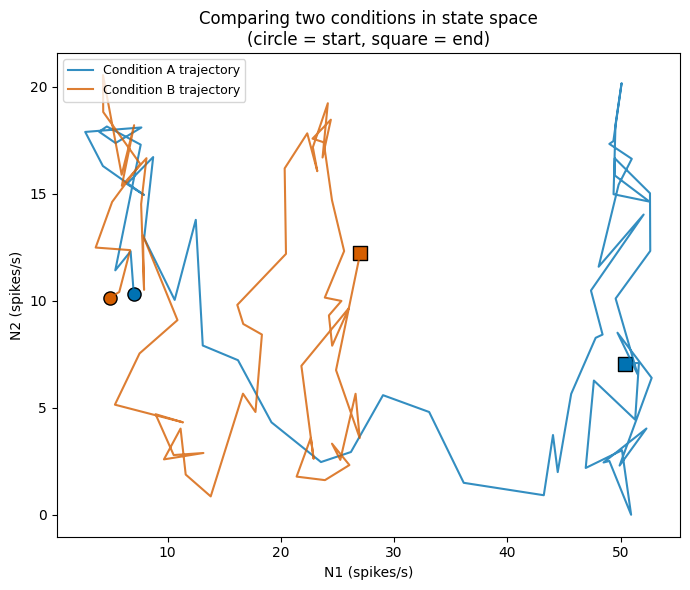

In [ ]:
# Comparing two experimental conditions as two trajectories
ramp_b = sigmoid((np.arange(n_bins) - (stim_onset_bin + 5)) / 5.0)   # condition B: slower onset
n1_b = 5.0 + 20.0 * ramp_b
n2_b = 10.0 + 8.0 * np.sin(2 * np.pi * time_axis / 1.5)
noise_b = RNG.normal(0.0, 1.5, size=n_bins)
trace_b = np.stack([n1_b, n2_b], axis=1) + np.stack([noise_b, RNG.normal(0, 1.5, n_bins)], axis=1)
trace_b = np.clip(trace_b, 0, None)

trace_a_2d = population_recording[:, :2]   # condition A, first two neurons only, for a clean 2D view

fig, ax = plt.subplots(figsize=(7, 6))
for traj_2d, color, label in [(trace_a_2d, PALETTE[0], 'Condition A trajectory'),
                               (trace_b, PALETTE[1], 'Condition B trajectory')]:
    ax.plot(traj_2d[:, 0], traj_2d[:, 1], '-', color=color, alpha=0.8, label=label)
    ax.scatter(traj_2d[0, 0], traj_2d[0, 1], color=color, marker='o', s=90, edgecolor='black')
    ax.scatter(traj_2d[-1, 0], traj_2d[-1, 1], color=color, marker='s', s=90, edgecolor='black')

ax.set_xlabel('N1 (spikes/s)'); ax.set_ylabel('N2 (spikes/s)')
ax.set_title('Comparing two conditions in state space\n(circle = start, square = end)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


#### Animation

The animation advances both conditions with the same time index, so their locations can be compared moment by moment.


In [ ]:
# INTERACTIVE ANIMATION -- both conditions advance together
all_x = np.concatenate([trace_a_2d[:, 0], trace_b[:, 0]])
all_y = np.concatenate([trace_a_2d[:, 1], trace_b[:, 1]])

fig_conditions_animation = go.Figure(
    data=[
        go.Scatter(x=trace_a_2d[:, 0], y=trace_a_2d[:, 1], mode='lines', line=dict(color=PALETTE[0], width=2), opacity=0.18, name='Condition A full route'),
        go.Scatter(x=trace_b[:, 0], y=trace_b[:, 1], mode='lines', line=dict(color=PALETTE[1], width=2), opacity=0.18, name='Condition B full route'),
        go.Scatter(x=trace_a_2d[:1, 0], y=trace_a_2d[:1, 1], mode='lines', line=dict(color=PALETTE[0], width=4), name='Condition A trajectory'),
        go.Scatter(x=trace_b[:1, 0], y=trace_b[:1, 1], mode='lines', line=dict(color=PALETTE[1], width=4), name='Condition B trajectory'),
        go.Scatter(x=[trace_a_2d[0, 0]], y=[trace_a_2d[0, 1]], mode='markers', marker=dict(color=PALETTE[0], size=15, line=dict(color='black', width=2)), name='Condition A current state'),
        go.Scatter(x=[trace_b[0, 0]], y=[trace_b[0, 1]], mode='markers', marker=dict(color=PALETTE[1], size=15, line=dict(color='black', width=2)), name='Condition B current state'),
    ],
    frames=[
        go.Frame(
            name=str(k),
            data=[
                go.Scatter(x=trace_a_2d[:k + 1, 0], y=trace_a_2d[:k + 1, 1]),
                go.Scatter(x=trace_b[:k + 1, 0], y=trace_b[:k + 1, 1]),
                go.Scatter(x=[trace_a_2d[k, 0]], y=[trace_a_2d[k, 1]]),
                go.Scatter(x=[trace_b[k, 0]], y=[trace_b[k, 1]]),
            ],
            traces=[2, 3, 4, 5],
        )
        for k in range(len(time_axis))
    ],
)
fig_conditions_animation.update_layout(
    title='Animated comparison of two conditions in state space',
    xaxis=dict(title='N1 (spikes/s)', range=list(padded_limits(all_x))),
    yaxis=dict(title='N2 (spikes/s)', range=list(padded_limits(all_y))),
    template='plotly_white', width=790, height=650,
    updatemenus=[dict(
        type='buttons', x=0.03, y=0.02, showactive=False,
        buttons=[
            dict(label='Play', method='animate', args=[None, {'frame': {'duration': 60, 'redraw': False}, 'transition': {'duration': 0}, 'fromcurrent': True}]),
            dict(label='Pause', method='animate', args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]),
        ],
    )],
    sliders=[dict(
        active=0, currentvalue={'prefix': 'time = ', 'suffix': ' s'},
        steps=[
            dict(label=f'{time_axis[k]:.2f}', method='animate', args=[[str(k)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': False}, 'transition': {'duration': 0}}])
            for k in range(len(time_axis))
        ],
    )],
)
fig_conditions_animation.show(config=PLOTLY_CONFIG)


# **Part 10: Mini-Lab — Following a Neural Population Through State Space**

This mini-lab combines everything from this lesson into one self-contained analysis. It uses
only the data already generated above and needs no internet access or external files.

**Your task, worked through below:**
1. Identify the population state at a selected time.
2. Explain the coordinates and units.
3. Compute the change between two selected states.
4. Compute magnitudes and a distance.
5. Normalise a response safely.
6. Visualize selected vectors and the trajectory.
7. Compare two experimental conditions.
8. Write a scientific interpretation and note a limitation.

In [ ]:
# Step 1-2: identify a population state and describe its coordinates
t_index_early, t_index_late = 5, 45   # arbitrary but fixed choices, before/after stimulus ramp

r_early = population_recording[t_index_early]
r_late  = population_recording[t_index_late]

print(f"State at t = {time_axis[t_index_early]:.2f} s: {r_early} spikes/s  (N1, N2, N3)")
print(f"State at t = {time_axis[t_index_late]:.2f} s: {r_late} spikes/s  (N1, N2, N3)")

# Step 3-4: change, magnitude, distance
delta = r_late - r_early
magnitude_early = np.linalg.norm(r_early)
magnitude_late  = np.linalg.norm(r_late)
distance_moved  = np.linalg.norm(delta)

print(f"\nState change (delta r): {delta} spikes/s")
print(f"||r_early|| = {magnitude_early:.2f}   ||r_late|| = {magnitude_late:.2f}")
print(f"Distance moved between the two states: {distance_moved:.2f} spikes/s")

# Step 5: safe normalisation
r_late_hat = normalise(r_late)
print(f"\nUnit vector of the late state: {r_late_hat}  (||.|| = {np.linalg.norm(r_late_hat):.3f})")

State at t = 0.25 s: [ 3.95908776 17.89319342  7.67491047] spikes/s  (N1, N2, N3)
State at t = 2.25 s: [49.54432954 10.09981872 26.95386311] spikes/s  (N1, N2, N3)

State change (delta r): [45.58524178 -7.7933747  19.27895264] spikes/s
||r_early|| = 19.87   ||r_late|| = 57.30
Distance moved between the two states: 50.10 spikes/s

Unit vector of the late state: [0.86466541 0.17626566 0.47040849]  (||.|| = 1.000)


In [ ]:
# INTERACTIVE ANIMATION -- time cursor and matching state move together
trace_y_min = float(np.min(population_recording))
trace_y_max = float(np.max(population_recording))

fig_linked_animation = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Firing-rate traces', 'Matching N1–N2 population state'),
    horizontal_spacing=0.12,
)

for i_neuron, label in enumerate(neuron_labels):
    fig_linked_animation.add_trace(go.Scatter(
        x=time_axis, y=population_recording[:, i_neuron], mode='lines',
        name=label, line=dict(color=PALETTE[i_neuron], width=2),
    ), row=1, col=1)

# Moving time cursor in the left panel.
fig_linked_animation.add_trace(go.Scatter(
    x=[time_axis[0], time_axis[0]], y=[trace_y_min, trace_y_max],
    mode='lines', line=dict(color='black', width=3, dash='dash'),
    name='current time',
), row=1, col=1)

# Full route and moving current state in the right panel.
fig_linked_animation.add_trace(go.Scatter(
    x=population_recording[:, 0], y=population_recording[:, 1],
    mode='lines', line=dict(color='lightgrey', width=2),
    name='complete N1–N2 route',
), row=1, col=2)
fig_linked_animation.add_trace(go.Scatter(
    x=population_recording[:1, 0], y=population_recording[:1, 1],
    mode='lines', line=dict(color=PALETTE[2], width=4),
    name='route so far',
), row=1, col=2)
fig_linked_animation.add_trace(go.Scatter(
    x=[population_recording[0, 0]], y=[population_recording[0, 1]],
    mode='markers', marker=dict(color='white', size=16, line=dict(color='black', width=3)),
    name='current population state',
), row=1, col=2)
fig_linked_animation.add_trace(go.Scatter(
    x=[r_early[0]], y=[r_early[1]], mode='markers',
    marker=dict(color=PALETTE[0], size=14), name='selected early state',
), row=1, col=2)
fig_linked_animation.add_trace(go.Scatter(
    x=[r_late[0]], y=[r_late[1]], mode='markers',
    marker=dict(color=PALETTE[1], size=14, symbol='square'), name='selected late state',
), row=1, col=2)

fig_linked_animation.frames = tuple(
    go.Frame(
        name=str(k),
        data=[
            go.Scatter(x=[time_axis[k], time_axis[k]], y=[trace_y_min, trace_y_max]),
            go.Scatter(x=population_recording[:k + 1, 0], y=population_recording[:k + 1, 1]),
            go.Scatter(x=[population_recording[k, 0]], y=[population_recording[k, 1]]),
        ],
        traces=[3, 5, 6],
    )
    for k in range(len(time_axis))
)

fig_linked_animation.update_xaxes(title_text='Time (s)', range=[time_axis.min(), time_axis.max()], row=1, col=1)
fig_linked_animation.update_yaxes(title_text='Firing rate (spikes/s)', range=list(padded_limits(population_recording.ravel())), row=1, col=1)
fig_linked_animation.update_xaxes(title_text='N1 (spikes/s)', range=list(padded_limits(population_recording[:, 0])), row=1, col=2)
fig_linked_animation.update_yaxes(title_text='N2 (spikes/s)', range=list(padded_limits(population_recording[:, 1])), row=1, col=2)
fig_linked_animation.update_layout(
    title='Animated link between time traces and state-space movement',
    template='plotly_white', width=1200, height=590,
    updatemenus=[dict(
        type='buttons', x=0.03, y=0.02, showactive=False,
        buttons=[
            dict(label='Play', method='animate', args=[None, {'frame': {'duration': 60, 'redraw': False}, 'transition': {'duration': 0}, 'fromcurrent': True}]),
            dict(label='Pause', method='animate', args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]),
        ],
    )],
    sliders=[dict(
        active=0, currentvalue={'prefix': 'time = ', 'suffix': ' s'},
        steps=[
            dict(label=f'{time_axis[k]:.2f}', method='animate', args=[[str(k)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': False}, 'transition': {'duration': 0}}])
            for k in range(len(time_axis))
        ],
    )],
)
fig_linked_animation.show(config=PLOTLY_CONFIG)


In [ ]:
# Step 7: compare condition A (this recording) against condition B from Part 9
distance_A_vs_B_start = np.linalg.norm(population_recording[0, :2] - trace_b[0])
distance_A_vs_B_end   = np.linalg.norm(population_recording[-1, :2] - trace_b[-1])

print(f"Distance between conditions A and B at the start: {distance_A_vs_B_start:.2f} spikes/s")
print(f"Distance between conditions A and B at the end:   {distance_A_vs_B_end:.2f} spikes/s")

Distance between conditions A and B at the start: 2.12 spikes/s
Distance between conditions A and B at the end:   23.97 spikes/s


**Interpretation:** the population state
moved a measurable Euclidean distance between the early and late time points, and its
direction of movement shows which neurons drove that
change the most. Conditions A and B start closer together than they end up — consistent
with the two stimuli driving increasingly distinct population patterns
over time.

**Limitation:** this entire analysis used Euclidean distance on raw firing rates, with no
correction for the very different firing-rate ranges of N1/N2/N3, and it used the first two
neurons only for the 2D panels above. A different choice of neurons to display, or a
different distance measure, could change the numeric picture without changing the underlying
recording.

## Part 12: Lesson 2 preview

Lesson 2 introduces the **dot product**, the **angle between two vectors**, **cosine
similarity**, and **projection** — the tools that let us ask not just *how far apart* two
vectors are, but *how aligned* their directions are. None of that is used here; Lesson 1 only
built the vectors these tools will operate on.